# Actividad 1 · Regresión lineal múltiple
## Estimación de la potencia máxima mensual de electricidad

**Pregunta:** ¿Qué tan bien podemos estimar la potencia máxima mensual a partir de la demanda residencial, comercial e industrial, de grandes usuarios y la temperatura promedio?

Se aplica aprendizaje supervisado: los coeficientes se aprenden a partir de observaciones históricas. El objetivo es continuo, aunque algunos valores estén registrados sin decimales.

**Alcance:** estimación con información del mismo mes. No es un pronóstico anticipado: para usarlo antes de que termine el mes habría que disponer de estimaciones de las entradas o reformularlo con datos rezagados.

**Uso:** ejecutar las celdas en orden. En Jupyter, colocar el CSV junto al cuaderno. En Google Colab, la celda de carga permite subirlo. El archivo original se lee sin modificarlo.


**Organización del trabajo:** se siguen las tres etapas de la Actividad 1 de la Clase 4: preparación y organización, exploración y modelado. Se incorporan las aclaraciones del resumen de clase sincrónica: al menos tres o cuatro predictoras, tratamiento justificado de nulos, evaluación e interpretación de coeficientes y residuos. La conversión de categóricas no aplica porque las cuatro entradas son numéricas.

El código se presenta en celdas ejecutables y las decisiones y conclusiones en celdas Markdown. Las salidas se conservan para poder leer el trabajo en Jupyter Notebook.

## 1. Preparación y organización

**Origen:** recurso «Demanda de electricidad. Datos mensuales», publicado por la Subsecretaría de Programación Macroeconómica en Datos Argentina. Se trabaja con el archivo aportado por el estudiante, sin descargar actualizaciones.

[Ficha del recurso y unidades](https://www.datos.gob.ar/fi/dataset/sspm_367/archivo/sspm_367.3)

El ámbito es la demanda eléctrica agregada de Argentina; cada fila representa un mes, no una persona ni un hogar. El CSV no detalla el procedimiento de recopilación ni la cobertura exacta del sistema; no se afirma que sea una encuesta o un censo.

| Función | Variable | Unidad |
|---|---|---|
| Objetivo | `potencia_maxima` | MW |
| Predictora | `demanda_residencial` | GWh |
| Predictora | `comercio_e_industria` | GWh |
| Predictora | `grandes_usuarios` | GWh |
| Predictora | `temperatura_promedio` | °C |
| Orden temporal | `indice_tiempo` | Fecha mensual |

La energía mensual y el pico de potencia son magnitudes diferentes: las demandas sectoriales no determinan el pico mediante una suma explícita. La coincidencia de los consumos en el tiempo también influye.


In [ ]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from IPython.display import display
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import (mean_absolute_error, mean_squared_error,
                             median_absolute_error, explained_variance_score, r2_score)

pd.set_option('display.max_rows', 40)
plt.rcParams.update({'figure.figsize': (10, 4), 'axes.grid': True, 'grid.alpha': 0.2})
archivo = Path('demanda-de-electricidad-datos-mensuales.csv')
if not archivo.exists():
    try:
        from google.colab import files
    except ImportError:
        raise FileNotFoundError('Colocá el CSV junto al cuaderno o ajustá la ruta de archivo.')
    subidos = files.upload()
    if archivo.name not in subidos:
        raise FileNotFoundError(f'Subí el archivo {archivo.name}')
df = pd.read_csv(archivo)
print('Filas y columnas:', df.shape)
display(df.head())
display(pd.DataFrame({'tipo_leído': df.dtypes, 'nulos': df.isna().sum()}))


Filas y columnas: (308, 30)


,indice_tiempo,demanda_total,demanda_residencial,comercio_e_industria,grandes_usuarios,temperatura_promedio,potencia_maxima,ede_tucuman,edelap_sa,edenor_distribuidor,...,energia_de_catamarca_sa,energia_de_entre_rios_sa,energia_de_mendoza_sa,energia_san_juan_sa_exedessa,epec_distribuidor,epen_distribuidor,epesf_distribuidor,recursos_y_energia_formosa_sa,secheep,spse_santa_cruz
0,2001-01-01,6866.26,NaN,NaN,NaN,25.432,13501.0,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2001-02-01,6473.10,NaN,NaN,NaN,25.596,14061.0,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2001-03-01,6952.30,NaN,NaN,NaN,22.852,13780.0,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2001-04-01,6183.35,NaN,NaN,NaN,18.317,12866.0,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2001-05-01,6668.94,NaN,NaN,NaN,14.306,12968.0,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


,tipo_leído,nulos
indice_tiempo,object,0
demanda_total,float64,0
demanda_residencial,float64,48
comercio_e_industria,float64,48
grandes_usuarios,float64,48
temperatura_promedio,float64,0
potencia_maxima,float64,0
ede_tucuman,float64,158
edelap_sa,float64,158
edenor_distribuidor,float64,158


In [2]:
df['indice_tiempo'] = pd.to_datetime(df['indice_tiempo'], errors='raise')
df = df.sort_values('indice_tiempo').reset_index(drop=True)
print('Período:', df.indice_tiempo.min().date(), 'a', df.indice_tiempo.max().date())
print('Filas duplicadas:', df.duplicated().sum())
print('Fechas duplicadas:', df.indice_tiempo.duplicated().sum())
meses = pd.date_range(df.indice_tiempo.min(), df.indice_tiempo.max(), freq='MS')
print('Meses ausentes:', len(meses.difference(df.indice_tiempo)))
assert not df.indice_tiempo.duplicated().any(), 'Revisar fechas duplicadas antes de continuar.'

sectores = ['demanda_residencial', 'comercio_e_industria', 'grandes_usuarios']
completos = df.dropna(subset=['demanda_total'] + sectores)
diferencia = completos['demanda_total'] - completos[sectores].sum(axis=1)
print('Filas para comprobar la suma:', len(completos))
print('Diferencia absoluta máxima entre total y suma sectorial:', diferencia.abs().max())


Período: 2001-01-01 a 2026-08-01
Filas duplicadas: 0
Fechas duplicadas: 0
Meses ausentes: 0
Filas para comprobar la suma: 260
Diferencia absoluta máxima entre total y suma sectorial: 3.637978807091713e-12


### Decisiones de limpieza y selección

- No utilizamos `demanda_total` como objetivo de las tres demandas sectoriales: la comprobación muestra que es su suma, salvo precisión numérica. Tampoco la añadimos como predictora redundante.
- Conservamos las cuatro predictoras acordadas. Las demandas describen actividad eléctrica y la temperatura puede influir en calefacción y refrigeración.
- Las demandas sectoriales faltan durante los primeros 48 meses. Se excluyen esas filas **solo del conjunto de modelado**, sin inventar consumos ni modificar el CSV.
- No eliminamos filas por nulos en las distribuidoras, porque esas columnas no se utilizan. Incluirlas reduciría innecesariamente el período disponible y agregaría variables relacionadas con consumos ya representados.
- La fecha se convierte y se usa para ordenar y separar los datos. No se incorpora como un identificador numérico al modelo.
- No hay variables categóricas entre las entradas elegidas; por eso no corresponde aplicar `get_dummies`.
- No se eliminan extremos automáticamente: un pico eléctrico puede ser una observación válida. Se inspecciona su distribución.


In [ ]:
predictoras = sectores + ['temperatura_promedio']
objetivo = 'potencia_maxima'
datos = df[['indice_tiempo'] + predictoras + [objetivo]].dropna().copy()
assert np.isfinite(datos[predictoras + [objetivo]].to_numpy()).all()
print('Filas excluidas por nulos en variables seleccionadas:', len(df) - len(datos))
print('Filas disponibles:', len(datos))
print('Nulos restantes:', datos.isna().sum().sum())

# La división cronológica se fija antes de explorar relaciones para no ajustar
# nuestras decisiones a los resultados de prueba.
entrenamiento, prueba = train_test_split(datos, test_size=0.20, shuffle=False)
for nombre, parte in [('Entrenamiento', entrenamiento), ('Prueba', prueba)]:
    print(nombre, len(parte), 'meses:', parte.indice_tiempo.min().date(),
          'a', parte.indice_tiempo.max().date())
assert entrenamiento.indice_tiempo.max() < prueba.indice_tiempo.min()

Filas excluidas por nulos en variables seleccionadas: 48
Filas disponibles: 260
Nulos restantes: 0
Entrenamiento 208 meses: 2005-01-01 a 2022-04-01
Prueba 52 meses: 2022-05-01 a 2026-08-01


## 2. Exploración de datos

Las relaciones y distribuciones se exploran sobre **entrenamiento**. El bloque posterior se reserva para evaluar el modelo. La separación 80/20 mantiene el orden temporal porque las observaciones son meses consecutivos; mezclarlos aleatoriamente dificultaría evaluar el desempeño en un período posterior.


,demanda_residencial,comercio_e_industria,grandes_usuarios,temperatura_promedio,potencia_maxima
count,208.00,208.00,208.00,208.00,208.00
mean,4021.16,3938.48,1984.81,18.62,20375.92
std,961.99,354.63,178.66,4.87,2890.75
min,2184.77,3261.45,1403.76,9.30,14552.00
25%,3218.56,3644.10,1903.58,14.30,17921.25
50%,3987.74,3932.11,1996.93,18.40,20382.50
75%,4669.68,4182.32,2114.78,22.92,22382.50
max,6521.32,4849.48,2333.80,27.00,28231.00


,demanda_residencial,comercio_e_industria,grandes_usuarios,temperatura_promedio,potencia_maxima
demanda_residencial,1.000,0.779,0.236,-0.076,0.905
comercio_e_industria,0.779,1.000,0.422,0.329,0.843
grandes_usuarios,0.236,0.422,1.000,0.017,0.328
temperatura_promedio,-0.076,0.329,0.017,1.000,0.148
potencia_maxima,0.905,0.843,0.328,0.148,1.000


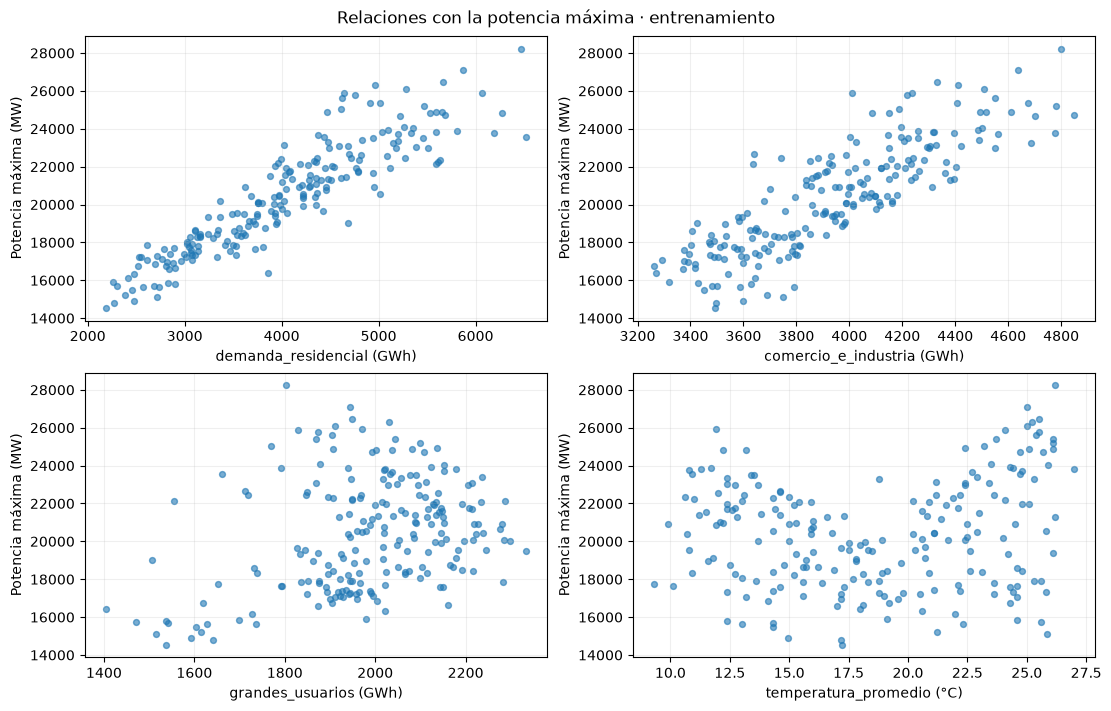

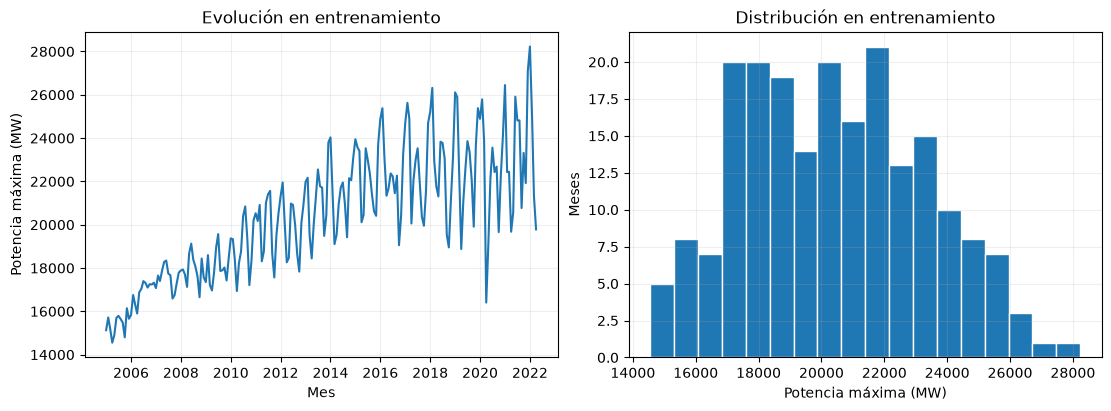

In [ ]:
display(entrenamiento[predictoras + [objetivo]].describe().round(2))
display(entrenamiento[predictoras + [objetivo]].corr().round(3))

fig, axes = plt.subplots(2, 2, figsize=(11, 7), constrained_layout=True)
for ax, variable in zip(axes.flat, predictoras):
    ax.scatter(entrenamiento[variable], entrenamiento[objetivo], alpha=0.6, s=18)
    unidad = '°C' if variable == 'temperatura_promedio' else 'GWh'
    ax.set_xlabel(f'{variable} ({unidad})')
    ax.set_ylabel('Potencia máxima (MW)')
fig.suptitle('Relaciones con la potencia máxima · entrenamiento')
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(11, 4), constrained_layout=True)
axes[0].plot(entrenamiento.indice_tiempo, entrenamiento[objetivo])
axes[0].set(title='Evolución en entrenamiento', ylabel='Potencia máxima (MW)', xlabel='Mes')
axes[1].hist(entrenamiento[objetivo], bins=18, edgecolor='white')
axes[1].set(title='Distribución en entrenamiento', xlabel='Potencia máxima (MW)', ylabel='Meses')
plt.show()

Las correlaciones describen asociación, no causalidad. Las demandas pueden compartir tendencias y estar correlacionadas entre sí, lo que dificulta separar sus efectos individuales. La temperatura media puede ocultar extremos y una relación no lineal: tanto el frío como el calor pueden elevar la demanda. Estas limitaciones no se resuelven eliminando observaciones sin una justificación.

## 3. Modelado

Se ajusta una regresión lineal múltiple con cuatro entradas. `fit` aprende el intercepto y los coeficientes exclusivamente con entrenamiento; `predict` los aplica a prueba. No se fijan coeficientes manualmente. No es necesario escalar las entradas para este ajuste ordinario; mantener sus unidades facilita la interpretación.


In [ ]:
X_train = entrenamiento[predictoras]
y_train = entrenamiento[objetivo]
X_test = prueba[predictoras]
y_test = prueba[objetivo]

modelo = LinearRegression()
modelo.fit(X_train, y_train)
pred_train = modelo.predict(X_train)
pred_test = modelo.predict(X_test)

coeficientes = pd.DataFrame({
    'variable': predictoras,
    'coeficiente': modelo.coef_,
    'unidad': ['MW/GWh', 'MW/GWh', 'MW/GWh', 'MW/°C']
})
print(f'Intercepto: {modelo.intercept_:.3f} MW')
display(coeficientes.round(4))

Intercepto: 1909.963 MW


,variable,coeficiente,unidad
0,demanda_residencial,2.3538,MW/GWh
1,comercio_e_industria,1.2133,MW/GWh
2,grandes_usuarios,1.2481,MW/GWh
3,temperatura_promedio,93.7250,MW/°C


In [ ]:
def evaluar(reales, estimados):
    return {
        'MAE (MW)': mean_absolute_error(reales, estimados),
        'MSE (MW²)': mean_squared_error(reales, estimados),
        'RMSE (MW)': np.sqrt(mean_squared_error(reales, estimados)),
        'Mediana error absoluto (MW)': median_absolute_error(reales, estimados),
        'Varianza explicada': explained_variance_score(reales, estimados),
        'R²': r2_score(reales, estimados)
    }

# Referencia sencilla: estimar siempre la media de entrenamiento.
referencia = np.full(len(y_test), y_train.mean())
metricas = pd.DataFrame({
    'Regresión · entrenamiento': evaluar(y_train, pred_train),
    'Regresión · prueba': evaluar(y_test, pred_test),
    'Media de entrenamiento · prueba': evaluar(y_test, referencia)
}).T
display(metricas.round(3))

resultados = prueba[['indice_tiempo', objetivo]].copy()
resultados['estimacion_MW'] = pred_test
resultados['residuo_MW'] = y_test.to_numpy() - pred_test
display(resultados.head(10).round(2))
print('Residuo promedio (MW):', round(resultados.residuo_MW.mean(), 2))
print('Correlación de residuos consecutivos:', round(resultados.residuo_MW.autocorr(), 3))

,MAE (MW),MSE (MW²),RMSE (MW),Mediana error absoluto (MW),Varianza explicada,R²
Regresión · entrenamiento,766.758,9.692512e+05,984.506,588.945,0.883,0.883
Regresión · prueba,1141.101,2.167797e+06,1472.344,982.614,0.772,0.759
Media de entrenamiento · prueba,4568.598,2.777380e+07,5270.085,4487.082,0.000,-2.089


,indice_tiempo,potencia_maxima,estimacion_MW,residuo_MW
256,2022-05-01,25362.0,23602.24,1759.76
257,2022-06-01,26062.0,26479.94,-417.94
258,2022-07-01,24477.0,25654.18,-1177.18
259,2022-08-01,23389.0,23808.98,-419.98
260,2022-09-01,20194.0,20871.60,-677.60
261,2022-10-01,19630.0,20857.53,-1227.53
262,2022-11-01,26610.0,23578.19,3031.81
263,2022-12-01,28283.0,27338.48,944.52
264,2023-01-01,27420.0,28767.41,-1347.41
265,2023-02-01,28207.0,25301.81,2905.19


Residuo promedio (MW): 348.67
Correlación de residuos consecutivos: -0.064


### Cómo interpretar las métricas y los coeficientes

- **MAE:** error absoluto promedio, en MW. Menor es mejor.
- **MSE:** error cuadrático promedio, en MW²; penaliza errores grandes. Su raíz, **RMSE**, vuelve a MW.
- **Mediana del error absoluto:** error central, menos sensible a extremos.
- **R²:** compara los errores cuadrados con los de usar la media del objetivo del conjunto evaluado; puede ser negativo. No es un porcentaje de aciertos.
- **Varianza explicada:** compara la variación de los residuos con la del objetivo; puede ser alta aunque exista un sesgo medio.
- **Coeficientes:** cambio estimado de potencia, en MW, por una unidad adicional de una entrada, manteniendo las demás constantes. No prueban efectos causales y no deben compararse como importancia sin considerar sus escalas y correlaciones.
- **Intercepto:** estimación cuando todas las entradas son cero; está fuera del contexto habitual y no tiene por qué tener una interpretación física útil.
- **Residuo = real − estimado:** positivo significa subestimación; negativo, sobreestimación. Una correlación entre residuos consecutivos sugiere estructura temporal no capturada, sin constituir por sí sola una prueba formal.


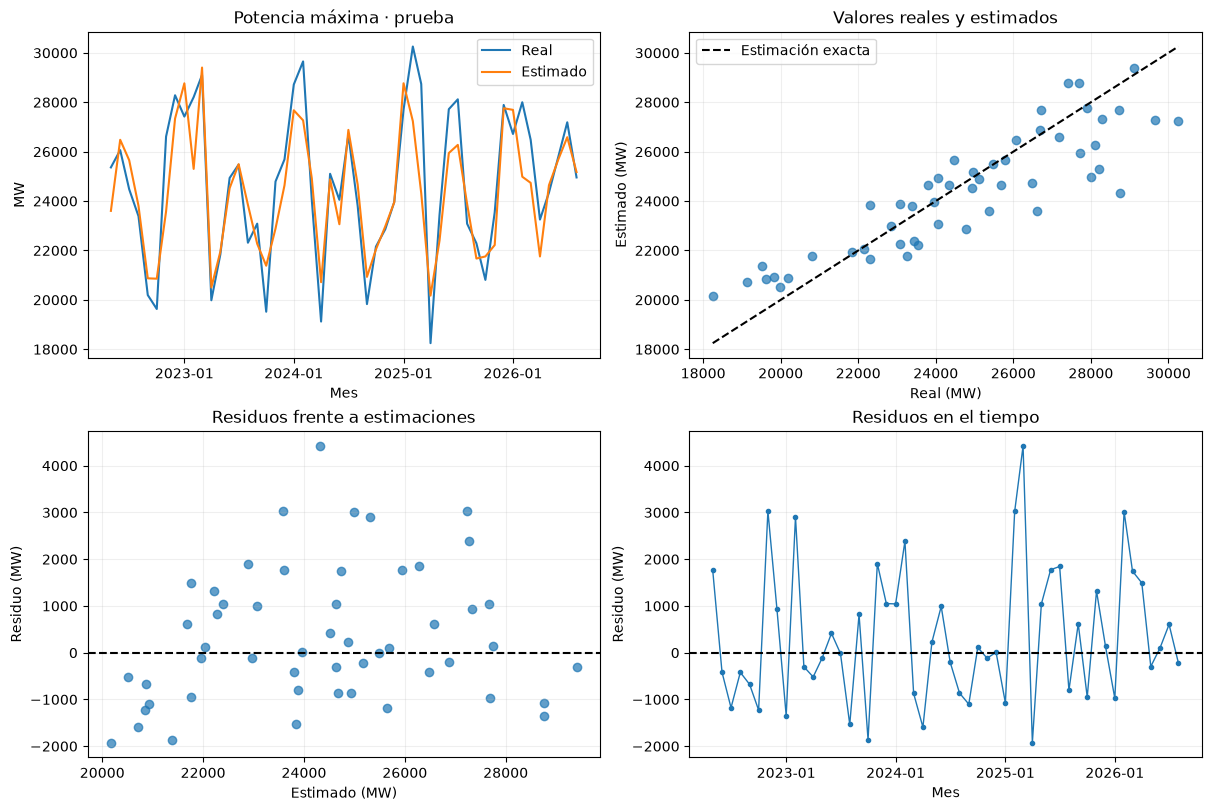

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8), constrained_layout=True)
ax = axes[0, 0]
ax.plot(resultados.indice_tiempo, y_test, label='Real')
ax.plot(resultados.indice_tiempo, pred_test, label='Estimado')
ax.set(title='Potencia máxima · prueba', xlabel='Mes', ylabel='MW')
ax.legend()
ax = axes[0, 1]
ax.scatter(y_test, pred_test, alpha=0.7)
limites = [min(y_test.min(), pred_test.min()), max(y_test.max(), pred_test.max())]
ax.plot(limites, limites, '--', color='black', label='Estimación exacta')
ax.set(title='Valores reales y estimados', xlabel='Real (MW)', ylabel='Estimado (MW)')
ax.legend()
ax = axes[1, 0]
ax.scatter(pred_test, resultados.residuo_MW, alpha=0.7)
ax.axhline(0, color='black', linestyle='--')
ax.set(title='Residuos frente a estimaciones', xlabel='Estimado (MW)', ylabel='Residuo (MW)')
ax = axes[1, 1]
ax.plot(resultados.indice_tiempo, resultados.residuo_MW, marker='.', linewidth=1)
ax.axhline(0, color='black', linestyle='--')
ax.set(title='Residuos en el tiempo', xlabel='Mes', ylabel='Residuo (MW)')
for ax in [axes[0, 0], axes[1, 1]]:
    ax.xaxis.set_major_locator(mdates.AutoDateLocator(minticks=3, maxticks=5))
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
plt.show()

In [ ]:
mae = mean_absolute_error(y_test, pred_test)
r2 = r2_score(y_test, pred_test)
mejora = 100 * (1 - mae / mean_absolute_error(y_test, referencia))
print(f'En los {len(y_test)} meses de prueba, el error absoluto promedio fue {mae:,.1f} MW.')
print(f'R² de prueba: {r2:.3f}.')
print(f'Reducción del MAE respecto de la media de entrenamiento: {mejora:.1f}%.')
print('Interpretación condicional de los coeficientes:')
for variable, coef in zip(predictoras, modelo.coef_):
    unidad = '°C' if variable == 'temperatura_promedio' else 'GWh'
    print(f'  Un aumento de 1 {unidad} en {variable} se asocia con {coef:+.3f} MW, '
          'manteniendo las otras entradas constantes.')

En los 52 meses de prueba, el error absoluto promedio fue 1,141.1 MW.
R² de prueba: 0.759.
Reducción del MAE respecto de la media de entrenamiento: 75.0%.
Interpretación condicional de los coeficientes:
  Un aumento de 1 GWh en demanda_residencial se asocia con +2.354 MW, manteniendo las otras entradas constantes.
  Un aumento de 1 GWh en comercio_e_industria se asocia con +1.213 MW, manteniendo las otras entradas constantes.
  Un aumento de 1 GWh en grandes_usuarios se asocia con +1.248 MW, manteniendo las otras entradas constantes.
  Un aumento de 1 °C en temperatura_promedio se asocia con +93.725 MW, manteniendo las otras entradas constantes.


## 4. Conclusión e interpretación de los resultados

**Se obtuvo una regresión lineal múltiple que mejora la referencia simple en el período de prueba, aunque presenta errores relevantes en algunos meses.**

Se utilizaron 260 meses completos. El entrenamiento comprende enero de 2005 a abril de 2022 (208 meses) y la prueba mayo de 2022 a agosto de 2026 (52 meses). Se excluyeron los primeros 48 registros por ausencia de demandas sectoriales; no se imputó la variable objetivo ni se alteró el CSV.

### Desempeño observado

| Métrica | Entrenamiento | Prueba |
|---|---:|---:|
| MAE (MW) | 766,76 | 1.141,10 |
| MSE (MW²) | 969.251,2 | 2.167.797 aprox. |
| RMSE (MW) | 984,51 | 1.472,34 |
| Mediana del error absoluto (MW) | 588,94 | 982,61 |
| Varianza explicada | 0,883 | 0,772 |
| R² | 0,883 | 0,759 |

El MAE de prueba significa que las estimaciones se apartan, en promedio absoluto, **1.141,10 MW** de la potencia registrada. El RMSE mayor que el MAE indica que existen errores de mayor magnitud que reciben más peso al elevarse al cuadrado. El R² de 0,759 representa una reducción aproximada del 75,9 % del error cuadrático respecto de usar la media de los valores reales de prueba; **no significa 75,9 % de aciertos**.

La referencia que predice siempre la media de **entrenamiento** obtiene un MAE de 4.568,60 MW. La regresión reduce ese MAE en aproximadamente 75 %. Esta es una comparación básica, no demuestra que el modelo supere a todos los métodos de series temporales.

El error aumenta al pasar de entrenamiento a prueba y el R² disminuye. Esto muestra una pérdida de desempeño en el período posterior; por sí solo no permite atribuirla exclusivamente a sobreajuste, porque también puede haber cambios temporales en las relaciones.

### Coeficientes aprendidos

La ecuación ajustada, con coeficientes redondeados, es:

$$\widehat{P} = 1909{,}963 + 2{,}354 R + 1{,}213 C + 1{,}248 G + 93{,}725 T$$

Aquí $P$ es la potencia máxima en MW; $R$, $C$ y $G$ son las demandas residencial, de comercio e industria y de grandes usuarios en GWh; y $T$ es la temperatura promedio en °C.

Manteniendo las otras entradas constantes, un aumento de 1 GWh de demanda residencial se asocia con 2,354 MW adicionales estimados. Para comercio e industria la asociación es de 1,213 MW/GWh, y para grandes usuarios, 1,248 MW/GWh. El coeficiente de temperatura es de 93,725 MW/°C. Son asociaciones condicionadas al resto de las variables, no efectos causales; la correlación entre demandas limita su interpretación individual.

### Exploración y residuos

En entrenamiento, la potencia máxima presenta correlaciones de 0,905 con demanda residencial, 0,843 con comercio e industria, 0,328 con grandes usuarios y 0,148 con temperatura. La asociación lineal simple con temperatura es débil. La demanda residencial y la comercial e industrial también están relacionadas entre sí (0,779). Los gráficos muestran tendencia temporal y variabilidad: no se trata de observaciones independientes tomadas al azar de una población estable.

Los gráficos de prueba muestran que el modelo sigue parte de las subidas y bajadas, pero subestima varios picos y suaviza algunos mínimos. Los residuos no se concentran todos cerca de cero: hay errores positivos superiores a 4.000 MW. El residuo medio es **+348,67 MW**, lo que indica una subestimación promedio. La correlación entre residuos de meses consecutivos es **−0,064**: es pequeña en esta muestra, pero no demuestra independencia ni descarta dependencias estacionales. No se afirma que los residuos sean normales o tengan varianza constante sin realizar comprobaciones adicionales.

### Alcance y límites

El ejercicio cumple el planteo de una variable objetivo continua y cuatro predictoras con relación razonable, sin reconstruir una suma conocida. El modelo estima el pico con consumos y temperatura del mismo mes: **no acredita capacidad para anticiparlo antes de conocer esas entradas**. El desempeño corresponde a esta partición temporal.

La temperatura promedio puede ocultar extremos, el efecto térmico puede ser no lineal y las relaciones pueden cambiar con el tiempo. No se ajustaron variables o hiperparámetros repetidamente para mejorar este bloque de prueba. Como extensión posterior podrían evaluarse estacionalidad, datos rezagados y términos no lineales mediante validación temporal dentro de entrenamiento, reservando otro período final independiente.

Los resultados numéricos de esta conclusión corresponden al CSV entregado. Si se reemplaza el archivo por una actualización, es necesario volver a ejecutar y revisar también este texto.
